# Figure 4

## Define Figure 4 workflow


In [1]:
"""
Two-panel Figure 4 for SS316H.

Panel (a): rupture life vs single-parameter fractal stress,
           using specimen thickness only.
Panel (b): rupture life vs temperature-dependent geometry-corrected stress
           sigma*_T, with per-temperature fit lines and R^2 in the legend.

Axes: X = log10 rupture life (h), Y = log10 stress.

Colour scheme: high-contrast, colour-blind-friendly (Okabe-Ito).

Requirements: numpy, pandas, scipy, matplotlib, openpyxl

"""
import os
import numpy as np
import pandas as pd
from scipy.optimize import minimize, minimize_scalar
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

DATA_PATH = os.path.join("..", "Dataset", "Creep_Properties_Dataset.xlsx")
TEMPS     = [550, 600, 650, 700]   # 750 °C omitted
LAMBDA    = 0.0

# ----------------------------------------------------------------------
# 1. Load + filter SS316H
# ----------------------------------------------------------------------
def load_ss316h(path):
    df = pd.read_excel(path, sheet_name="Data", header=1)
    d = pd.DataFrame({
        "alloy": df.iloc[:, 2].astype(str).str.strip(),
        "notch": df.iloc[:, 48].astype(str).str.strip(),
        "b":     pd.to_numeric(df.iloc[:, 46], errors="coerce"),
        "A":     pd.to_numeric(df.iloc[:, 50], errors="coerce"),
        "LD":    pd.to_numeric(df.iloc[:, 49], errors="coerce"),
        "sigma": pd.to_numeric(df.iloc[:, 53], errors="coerce"),
        "temp":  pd.to_numeric(df.iloc[:, 54], errors="coerce"),
        "tR":    pd.to_numeric(df.iloc[:, 55], errors="coerce"),
    })
    m = ((d.alloy == "SS316H") & (d.notch == "unnotched") &
         (d.sigma > 0) & (d.tR > 0) & (d.temp > 0) &
         (d.b > 0) & (d.A > 0) & (d.LD > 0))
    return d[m].dropna(subset=["b", "A", "LD"]).reset_index(drop=True)

# ----------------------------------------------------------------------
# 2. Collapse-loss helper
# ----------------------------------------------------------------------
def within_temperature_rss(lx, y, groups):
    def rss(lx):
        r = 0.0
        for ii in groups:
            if len(ii) < 4: r += ((y[ii]-y[ii].mean())**2).sum(); continue
            x = lx[ii]; v = y[ii]; Sxx = ((x-x.mean())**2).sum()
            if Sxx < 1e-12: r += ((v-v.mean())**2).sum(); continue
            Sxy = ((x-x.mean())*(v-v.mean())).sum(); r += ((v-v.mean())**2).sum() - Sxy*Sxy/Sxx
        return r
    return rss(lx)

# ----------------------------------------------------------------------
# 3. Fit single-parameter fractal stress
# ----------------------------------------------------------------------
def fit_single_fractal(s):
    s = s.reset_index(drop=True)
    b0 = s.b.median()
    lb = np.log10(s.b / b0).values
    lsig = np.log10(s.sigma).values
    y = np.log10(s.tR).values
    tr = s.temp.round().astype(int).values
    groups = [np.where(tr == t)[0] for t in np.unique(tr)]

    def obj(alpha):
        lx = lsig + float(alpha) * lb
        return within_temperature_rss(lx, y, groups) / len(y)

    res = minimize_scalar(obj, bounds=(-0.8, 0.8), method="bounded")
    return lsig + float(res.x) * lb, float(res.x)

# ----------------------------------------------------------------------
# 4. Fit sigma*_T  (temperature-dependent geometry-corrected stress)
# ----------------------------------------------------------------------
def fit_sigmaT(s, lam=LAMBDA):
    s = s.reset_index(drop=True)
    b0, A0, L0 = s.b.median(), s.A.median(), s.LD.median()
    mu, sd = s.temp.mean(), s.temp.std()
    lb = np.log10(s.b / b0).values; lA = np.log10(s.A / A0).values; lL = np.log10(s.LD / L0).values
    lsig = np.log10(s.sigma).values; y = np.log10(s.tR).values; Tn = ((s.temp - mu) / sd).values
    tr = s.temp.round().astype(int).values
    groups = [np.where(tr == t)[0] for t in np.unique(tr)]

    def obj(p):
        a0,a1,be0,be1,g0,g1 = p
        lx = lsig + (a0+a1*Tn)*lb + (be0+be1*Tn)*lA + (g0+g1*Tn)*lL
        return within_temperature_rss(lx, y, groups)/len(y) + lam*np.mean((lx-lsig)**2)
    th = minimize(obj, np.zeros(6), method="Nelder-Mead",
                  options={"maxiter": 4000, "xatol": 1e-5, "fatol": 1e-8}).x
    a0,a1,be0,be1,g0,g1 = th
    return lsig + (a0+a1*Tn)*lb + (be0+be1*Tn)*lA + (g0+g1*Tn)*lL

# ----------------------------------------------------------------------
# 5. Plot
# ----------------------------------------------------------------------
def main():
    s = load_ss316h(DATA_PATH)
    lsingle, alpha = fit_single_fractal(s)
    s = s.assign(
        lsig=np.log10(s.sigma),
        lsingle=lsingle,
        lstar=fit_sigmaT(s),
        ltR=np.log10(s.tR),
    )
    s = s[s.temp.round().astype(int).isin(TEMPS)]

    # Okabe-Ito high-contrast palette
    palette = {550:"#0072B2", 600:"#F0944D", 650:"#009E73", 700:"#CC79A7"}
    plt.rcParams.update({
        "font.family": "serif", "font.size": 15, "axes.linewidth": 0.9,
        "axes.labelsize": 17, "xtick.labelsize": 15, "ytick.labelsize": 15,
    })
    fig, ax = plt.subplots(1, 2, figsize=(12.0, 5.6), constrained_layout=True)
    R2_single = {}
    R2_proposed = {}
    # ycol is the stress (Y axis); the X axis is rupture life ltR
    specs = [
        ("lsingle", r"Fractal stress  log$_{10}\,\sigma^{*}$",   r"(a) Fractal stress [34]",       True, False),
        ("lstar",   r"Proposed stress  log$_{10}\,\sigma^{*}_{T}$", r"(b) Our proposed method",    True, True),
    ]
    for col, (ycol, ylab, title, line, save_r2) in enumerate(specs):
        for T in TEMPS:
            g = s[s.temp.round() == T]; cc = palette[T]
            # X = rupture life, Y = stress
            ax[col].scatter(g.ltR, g[ycol], color=cc, s=24, edgecolor="k", linewidth=0.3, alpha=0.8)
            if line:
                # Fit stress ~ ltR
                X = np.column_stack([g.ltR, np.ones(len(g))]); bco, *_ = np.linalg.lstsq(X, g[ycol], rcond=None)
                xs = np.linspace(g.ltR.min(), g.ltR.max(), 30)
                ax[col].plot(xs, bco[0]*xs+bco[1], color=cc, lw=2.4)
                r2 = 1 - ((g[ycol] - X@bco)**2).sum() / (((g[ycol] - g[ycol].mean())**2).sum())
                if ycol == "lsingle":
                    R2_single[T] = r2
                if save_r2:
                    R2_proposed[T] = r2
        ax[col].set_xlabel(r"Rupture life  log$_{10}\,t_r$")
        ax[col].set_ylabel(ylab)
        ax[col].set_title(title, fontsize=17, fontweight="bold")
        ax[col].grid(alpha=0.2, lw=0.5)
        ax[col].spines["top"].set_visible(False); ax[col].spines["right"].set_visible(False)

    leg_single = [Line2D([0],[0], marker="o", color=palette[T], ls="-", lw=2.4, mec="k", mew=0.3, ms=8,
                         label=f"{T} °C  ($R^2$={R2_single[T]:.3f})") for T in TEMPS]
    ax[0].legend(handles=leg_single, title="Temperature", loc="lower left",
                 fontsize=13, title_fontsize=13.5, framealpha=0.92)

    leg_proposed = [Line2D([0],[0], marker="o", color=palette[T], ls="-", lw=2.4, mec="k", mew=0.3, ms=8,
                           label=f"{T} °C  ($R^2$={R2_proposed[T]:.3f})") for T in TEMPS]
    ax[1].legend(handles=leg_proposed, title="Temperature", loc="lower left",
                 fontsize=13, title_fontsize=13.5, framealpha=0.92)
    print(f"single-parameter alpha = {alpha:.5f}")
    plt.show()


## Generate Figure 4


single-parameter alpha = 0.33101


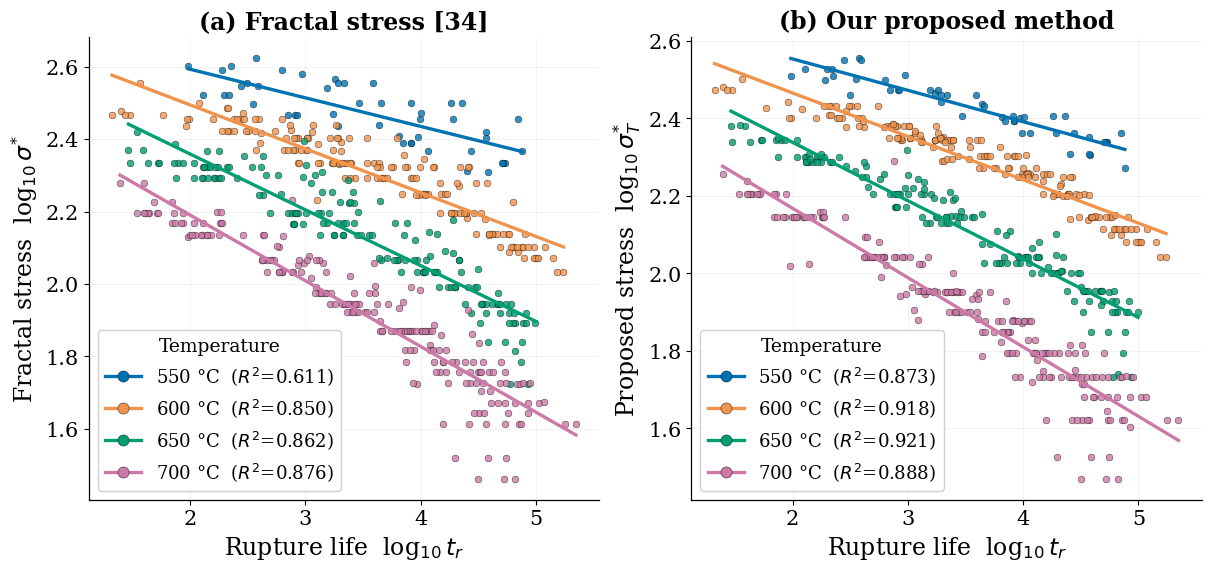

In [2]:
# Run Figure 4
main()